## Importações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

# years = [2019, 2020, 2021, 2022, 2023, 2024]
years = range(2014,2025)

# modes = {}
# graphs = {}

# base_modes = "../../data/03_modes"

# for year in years:
#     for speed in ["fast", "medium", "slow"]:
#         file_path = f"../../data/04_graphs/{year}/{speed}_graph.gpickle"
#         with open(file_path, "rb") as f:
#             graphs[f"graph_{speed}_{year}"] = pickle.load(f)
                    
#             modes[f"{speed}_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/{speed}_emd.parquet")

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k = 5

for year in years:
    file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_new_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

c:\Users\gustavo.roque_visagi\Desktop\paper-financial-graph\.venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
c:\Users\gustavo.roque_visagi\Desktop\paper-financial-graph\.venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


## Funções

In [2]:
import numpy as np
import networkx as nx
from sklearn.decomposition import PCA

def calculate_hybrid_risk_metric(G, use_pca=True, custom_weights=None):
    nodes = list(G.nodes)
    G = G.copy()
    
    for u, v, d in G.edges(data=True):
        # Euclidean distance transformation bounded between 0 and sqrt(2)
        d["distance"] = np.sqrt(2 * max(0.0, 1 - d["weight"]))
    
    # 1. Calculate raw metrics
    degree_dict = dict(nx.degree(G, weight="weight"))
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    eig_dict = nx.eigenvector_centrality_numpy(G, weight="weight")
    
    # Betweenness is calculated but not included in the hybrid metric per your thesis text
    # betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
    # 2. Standardize metrics using Z-scoring (mean=0, std=1)
    def standardize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        mean_val = vals.mean()
        std_val = vals.std()
        
        if std_val == 0:
            return {k: 0.0 for k in d.keys()}
            
        z_scores = {k: (v - mean_val) / std_val for k, v in d.items()}
        
        if invert:
            z_scores = {k: -v for k, v in z_scores.items()}
            
        return z_scores

    norm_degree = standardize_dict(degree_dict, invert=False)
    norm_closeness = standardize_dict(closeness_dict, invert=False)
    norm_eig = standardize_dict(eig_dict, invert=False)
    
    # 3. Determine Weights
    if use_pca:
        # Build feature matrix (N nodes x 3 metrics)
        features = np.array([
            [norm_degree[n], norm_closeness[n], norm_eig[n]] for n in nodes
        ])
        
        # Extract the First Principal Component
        pca = PCA(n_components=1)
        pca.fit(features)
        pc1_loadings = pca.components_[0]
        
        # PCA vectors can point in arbitrary directions. We take the absolute value
        # to ensure positive loadings, maintaining the logical direction of centrality.
        pc1_loadings = np.abs(pc1_loadings)
        
        # Normalize to sum to 1 (convex combination)
        pca_weights = pc1_loadings / np.sum(pc1_loadings)
        
        weights = {
            'degree': pca_weights[0],
            'closeness': pca_weights[1],
            'eigenvector': pca_weights[2]
        }
    else:
        # Fallback to custom or equal weights if PCA is disabled
        weights = custom_weights if custom_weights else {
            'degree': 1/3, 'closeness': 1/3, 'eigenvector': 1/3
        }

    # 4. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['closeness'] * norm_closeness[node] +
            weights['eigenvector'] * norm_eig[node] 
        )
        risk_scores[node] = score
    
    return risk_scores, weights, degree_dict, closeness_dict, eig_dict

In [3]:
def compute_pozzi_centrality(G, weight_attr="weight"):
    """
    Compute the Pozzi et al. (2013) composite centrality indicators X and Y.

    X aggregates degree + betweenness (both weighted/unweighted).
    Y aggregates eccentricity + closeness + eigenvector (both weighted/unweighted).

    Weighted degree / eigenvector use edge weight  : 1 + R_ij
    Weighted BC / eccentricity / closeness use      : sqrt(2 * (1 - R_ij))  (distance)

    Parameters
    ----------
    G           : nx.Graph with a correlation edge attribute
    weight_attr : str — name of the correlation weight attribute (default "weight")

    Returns
    -------
    pd.DataFrame with columns [Du, Dw, BCu, BCw, Eu, Ew, Cu, Cw, ECu, ECw, X, Y]
    indexed by node.
    """
    N = G.number_of_nodes()

    # --- Build two edge-weighted copies ---
    G_corr = nx.Graph()   # weight = 1 + R  (similarity, for D and EC)
    G_dist = nx.Graph()   # weight = sqrt(2*(1-R))  (distance, for BC/E/C)
    G_corr.add_nodes_from(G.nodes())
    G_dist.add_nodes_from(G.nodes())

    for u, v, data in G.edges(data=True):
        r = data.get(weight_attr, 0.0)
        G_corr.add_edge(u, v, weight=1.0 + r)
        G_dist.add_edge(u, v, weight=np.sqrt(2.0 * (1.0 - r)))

    # --- Unweighted centralities (normalized to [0,1]) ---
    Du  = nx.degree_centrality(G)
    BCu = nx.betweenness_centrality(G, normalized=True)
    Cu  = nx.closeness_centrality(G)
    ECu = nx.eigenvector_centrality_numpy(G)

    # --- Weighted centralities ---
    Dw  = nx.degree_centrality(G_corr)           # similarity weights
    BCw = nx.betweenness_centrality(G_dist, weight="weight", normalized=True)
    Cw  = nx.closeness_centrality(G_dist, distance="weight")
    ECw = nx.eigenvector_centrality_numpy(G_corr, weight="weight")

    # Eccentricity requires connected graph — fall back to largest component
    def _eccentricity(Gh):
        if nx.is_connected(Gh):
            raw = nx.eccentricity(Gh)
        else:
            lcc  = Gh.subgraph(max(nx.connected_components(Gh), key=len))
            raw  = nx.eccentricity(lcc)
            # nodes outside LCC get NaN
            raw  = {n: raw.get(n, np.nan) for n in Gh.nodes()}
        # normalise: invert (higher eccentricity = more peripheral)
        # and scale to [0,1] via min-max
        vals = np.array([v for v in raw.values() if not np.isnan(v)])
        lo, hi = vals.min(), vals.max()
        return {
            n: (raw[n] - lo) / (hi - lo) if not np.isnan(raw.get(n, np.nan)) else np.nan
            for n in Gh.nodes()
        }

    Eu = _eccentricity(G)
    Ew = _eccentricity(G_dist)

    # --- Assemble DataFrame ---
    nodes = list(G.nodes())
    df = pd.DataFrame(index=nodes)

    df["Du"]  = [Du[n]  for n in nodes]
    df["Dw"]  = [Dw[n]  for n in nodes]
    df["BCu"] = [BCu[n] for n in nodes]
    df["BCw"] = [BCw[n] for n in nodes]
    df["Eu"]  = [Eu[n]  for n in nodes]
    df["Ew"]  = [Ew[n]  for n in nodes]
    df["Cu"]  = [Cu[n]  for n in nodes]
    df["Cw"]  = [Cw[n]  for n in nodes]
    df["ECu"] = [ECu[n] for n in nodes]
    df["ECw"] = [ECw[n] for n in nodes]

    # --- Z-score standardization ---\n    cols = ["Du", "Dw", "BCu", "BCw", "Eu", "Ew", "Cu", "Cw", "ECu", "ECw"]\n    for col in cols:\n        df[col] = (df[col] - df[col].mean()) / df[col].std()\n\n    # --- Composite scores ---
    df["X"] = (df["Du"] + df["Dw"] + df["BCu"] + df["BCw"]) / 4
    df["Y"] = (df["Eu"] + df["Ew"] + df["Cu"]  + df["Cw"] + df["ECu"] + df["ECw"]) / 6

    df["metric"] = df["X"] + df["Y"]

    return df

## Construção do DataFrame com os nós e as métricas de grafos calculadas para cada modo

In [4]:
for name, G in graphs.items():
    print(name)

graph_2014
graph_2015
graph_2016
graph_2017
graph_2018
graph_2019
graph_2020
graph_2021
graph_2022
graph_2023
graph_2024


In [35]:
from tqdm.auto import tqdm
data = []

for name, G in tqdm(graphs.items(), desc="Calculando métricas dos grafos"):
    _, year = name.split("_")

    G = G.copy()
    for u, v, d in G.edges(data=True):
        d["distance"] = np.sqrt(2 * max(0.0, 1 - d["weight"]))

    # Aproveita as centralidades (degree, closeness, eig) já calculadas internamente 
    # pelo calculate_hybrid_risk_metric para não recalcular à toa. 
    # O nx.betweenness_centrality demorado e não utilizado foi removido.
    hrm, _, degree_dict, closeness_dict, eig_dict = calculate_hybrid_risk_metric(G)
    pozzi = compute_pozzi_centrality(G)

    for node in G.nodes():
        data.append({
            "node": node,
            "hrm": hrm[node],
            "pozzi": pozzi.loc[node, "metric"],
            "degree": degree_dict[node],
            "closeness": closeness_dict[node],
            "eig": eig_dict[node],
            "year": year
        })

df = pd.DataFrame(data)



/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Calculando métricas dos grafos: 100%|██████████| 11/11 [59:50<00:00, 326.43s/it]


## Fazer HRM = -HRM

In [1]:
import pandas as pd

df = pd.read_parquet("../../data/02_clean/df_metrics.parquet")

In [3]:
df["hrm"] = -df["hrm"]

In [4]:
import pandas as pd

# 1. Criamos os nomes das 10 fatias (Decil 1 até Decil 10)
decile_labels = [f"decil_{i}" for i in range(1, 11)]  # ['decil_1', 'decil_2', ..., 'decil_10']

for year in years:
    year_str = str(year)
    df_year = df[df["year"] == year_str].copy()
    
    # Se não houver dados para o ano, pula
    if df_year.empty:
        continue
        
    # Divide os dados em 10 partes iguais para cada uma das métricas
    df_year["decil_hrm"] = pd.qcut(df_year["hrm"], q=10, labels=decile_labels, duplicates='drop')
    df_year["decil_pozzi"] = pd.qcut(df_year["pozzi"], q=10, labels=decile_labels, duplicates='drop')
    
    # Carrega o arquivo de retornos do ano uma única vez para economizar memória e tempo
    try:
        returns_temp = pd.read_parquet(f"../../data/02_clean/returns_new_{year}.parquet")
    except FileNotFoundError:
        print(f"Arquivo de retornos para o ano {year} não encontrado. Pulando...")
        continue

    # 2. Iteramos sobre as fatias padrão (de decil_1 a decil_10)
    for label in decile_labels:
        for metric in ["hrm", "pozzi"]:
            # Filtra as ações que pertencem a este decil específico desta métrica específica
            portfolio_df = df_year[df_year[f"decil_{metric}"] == label]
            
            tickers_temp = portfolio_df["node"]
            valid_tickers = [t for t in tickers_temp if t in returns_temp.columns]
            
            # Se a fatia tiver tickers válidos, extrai os retornos e salva
            if valid_tickers:
                port_returns_temp = returns_temp[valid_tickers]
                
                # Nome do arquivo agora inclui o decil, o ano e qual foi a métrica usada (ex: decil_1_2024_hrm.parquet)
                # Dica: se precisar do {k}, mude para f"../../data/06_portfolios/{label}_{year}_{k}_{metric}.parquet"
                port_returns_temp.to_parquet(f"../../data/06_portfolios/{label}_{year}_{metric}.parquet")
                
                # Se quiser os metadados no futuro:
                # metadata_temp = get_portfolio_info(tickers_temp)
                # metadata_temp.to_csv(f"../../data/07_portfolios_metadata/{label}_metadata_{year}_{metric}_{k}.csv", index=False)

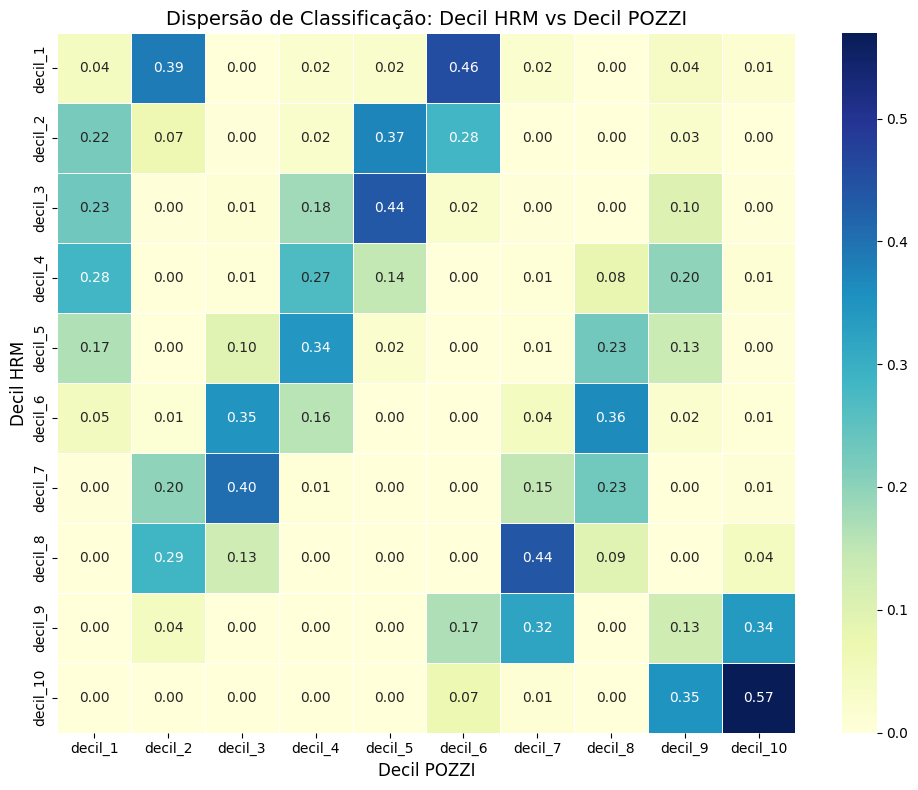

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criar a matriz de contagem cruzada entre os decis
# Usamos os labels ordenados para garantir que o gráfico vá do decil_1 ao decil_10 certinho
matriz_contingencia = pd.crosstab(
    df_year["decil_hrm"], 
    df_year["decil_pozzi"], 
    normalize="index"  # Mostra a proporção (porcentagem) em cada linha
)

# 2. Plotar o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_contingencia, 
    annot=True,          # Mostra os números dentro dos quadradinhos
    fmt=".2f",           # Formato com duas casas decimais
    cmap="YlGnBu",       # Cor do gradiente (amarelo para azul escuro)
    linewidths=.5
)

plt.title("Dispersão de Classificação: Decil HRM vs Decil POZZI", fontsize=14)
plt.xlabel("Decil POZZI", fontsize=12)
plt.ylabel("Decil HRM", fontsize=12)
plt.tight_layout()
plt.show()

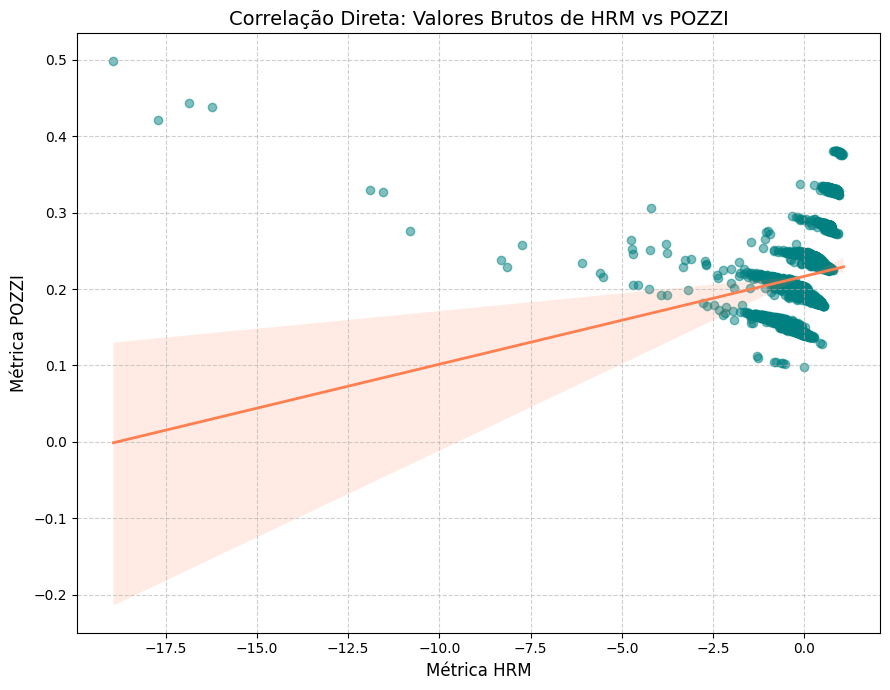

In [6]:
plt.figure(figsize=(9, 7))

# Plot dos pontos com uma linha de regressão linear para medir a tendência
sns.regplot(
    data=df_year, 
    x="hrm", 
    y="pozzi", 
    scatter_kws={"alpha": 0.5, "color": "teal"}, 
    line_kws={"color": "coral", "linewidth": 2}
)

plt.title("Correlação Direta: Valores Brutos de HRM vs POZZI", fontsize=14)
plt.xlabel("Métrica HRM", fontsize=12)
plt.ylabel("Métrica POZZI", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:
central_portfolios = {}
peripheral_portfolios = {}

q90 = df.groupby("year")["hrm"].quantile(0.9).reset_index(name="p90")
q10 = df.groupby("year")["hrm"].quantile(0.1).reset_index(name="p10")

for year in years:
    p90 = q90.loc[q90["year"] == str(year), "p90"].iloc[0]
    p10 = q10.loc[q10["year"] == str(year), "p10"].iloc[0]

    central_portfolios[year] = df[(df["year"] == str(year)) & (df["hrm"] > p90)]
    peripheral_portfolios[year] = df[(df["year"] == str(year)) & (df["hrm"] < p10)]

In [10]:
centralities = ["central", "peripheral"]

def get_portfolio_info(
        portfolio
):
    stock_info = pd.read_csv("../../data/02_clean/METADADOS_ATUALIZADO - Sheet1.csv")
    portfolio = portfolio.to_frame().rename(columns={"node":"Ticker"})
    return portfolio.merge(
        stock_info, on="Ticker", how="left"
    )

for year in years:
    central_temp = central_portfolios[year]["node"]
    peripheral_temp = peripheral_portfolios[year]["node"]
    returns_temp = pd.read_parquet(
        f"../../data/02_clean/returns_new_{year}.parquet"
    )
    central_port_temp = returns_temp[central_temp]
    peripheral_port_temp = returns_temp[peripheral_temp]

    # central_metadata_temp = get_portfolio_info(central_temp)
    # peripheral_metadata_temp = get_portfolio_info(peripheral_temp)

    central_port_temp.to_csv(f"../../data/06_portfolios/central_{year}_{k}.csv")
    peripheral_port_temp.to_csv(f"../../data/06_portfolios/peripheral_{year}_{k}.csv")

    # central_metadata_temp.to_csv(f"../../data/07_portfolios_metadata/central_metadata_{year}_{k}.csv")
    # peripheral_metadata_temp.to_csv(f"../../data/07_portfolios_metadata/peripheral_metadata_{year}_{k}.csv")

### Analysis of metrics

In [84]:
df = df.merge(pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")[["Ticker", "Sector"]],
         left_on="node", right_on="Ticker", how="inner")

In [85]:
# # --- 1. Sort and compute % change in HRM score per stock year-over-year ---
# df_sorted = df[["Ticker", "Sector", "year", "hrm"]].sort_values(["Ticker", "year"])

# df_sorted["hrm_pct_change"] = (
#     df_sorted.groupby("Ticker")["hrm"]
#     .pct_change()
#     .replace([np.inf, -np.inf], np.nan)  # ← treat as missing, excluded from mean
#     .mul(100)
# )

# # Drop first year (no previous value)
# df_shifted = df_sorted.dropna(subset=["hrm_pct_change"])

# # --- 2. Average % change per sector/year ---
# avg_pct = (
#     df_shifted.groupby(["Sector", "year"])["hrm_pct_change"]
#     .median()
#     .reset_index()
#     .rename(columns={"hrm_pct_change": "avg_pct_change"})
# )

# pivot = avg_pct.pivot(index="Sector", columns="year", values="avg_pct_change")

# # --- 3. Plot ---
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# fig, ax = plt.subplots(figsize=(14, 6))

# # Diverging colormap: red = declined, blue = increased
# abs_max = np.nanpercentile(np.abs(pivot.values), 95)  # robust symmetric scale

# sns.heatmap(
#     pivot,
#     ax=ax,
#     annot=True,
#     fmt=".1f",
#     cmap="Blues",
#     center=0,
#     vmin=-abs_max, vmax=abs_max,
#     linewidths=0.4,
#     linecolor="white",
#     cbar_kws={"shrink": 0.8},
#     annot_kws={"fontsize": 8}
# )

# ax.set_title(
#     "Median % Change in Hybrid Centrality Metric Score",
#     fontsize=12, fontweight="bold", pad=10
# )
# ax.set_xlabel("Year", fontsize=10)
# ax.set_ylabel("Sector", fontsize=10)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# plt.tight_layout()
# os.makedirs(f"../../figures/window_{k}/", exist_ok=True)
# plt.savefig(f"../../figures/window_{k}/median_change_hrm.png")
# plt.show()

In [86]:
final_df = pd.read_csv("../../data/02_clean/METADADOS_ATUALIZADO - Sheet1.csv")
beta_momentum = pd.read_csv("../../data/07_portfolios_metadata/beta_momentum.csv", index_col="Unnamed: 0")

final_df = final_df.merge(beta_momentum, on="Ticker", how="inner")

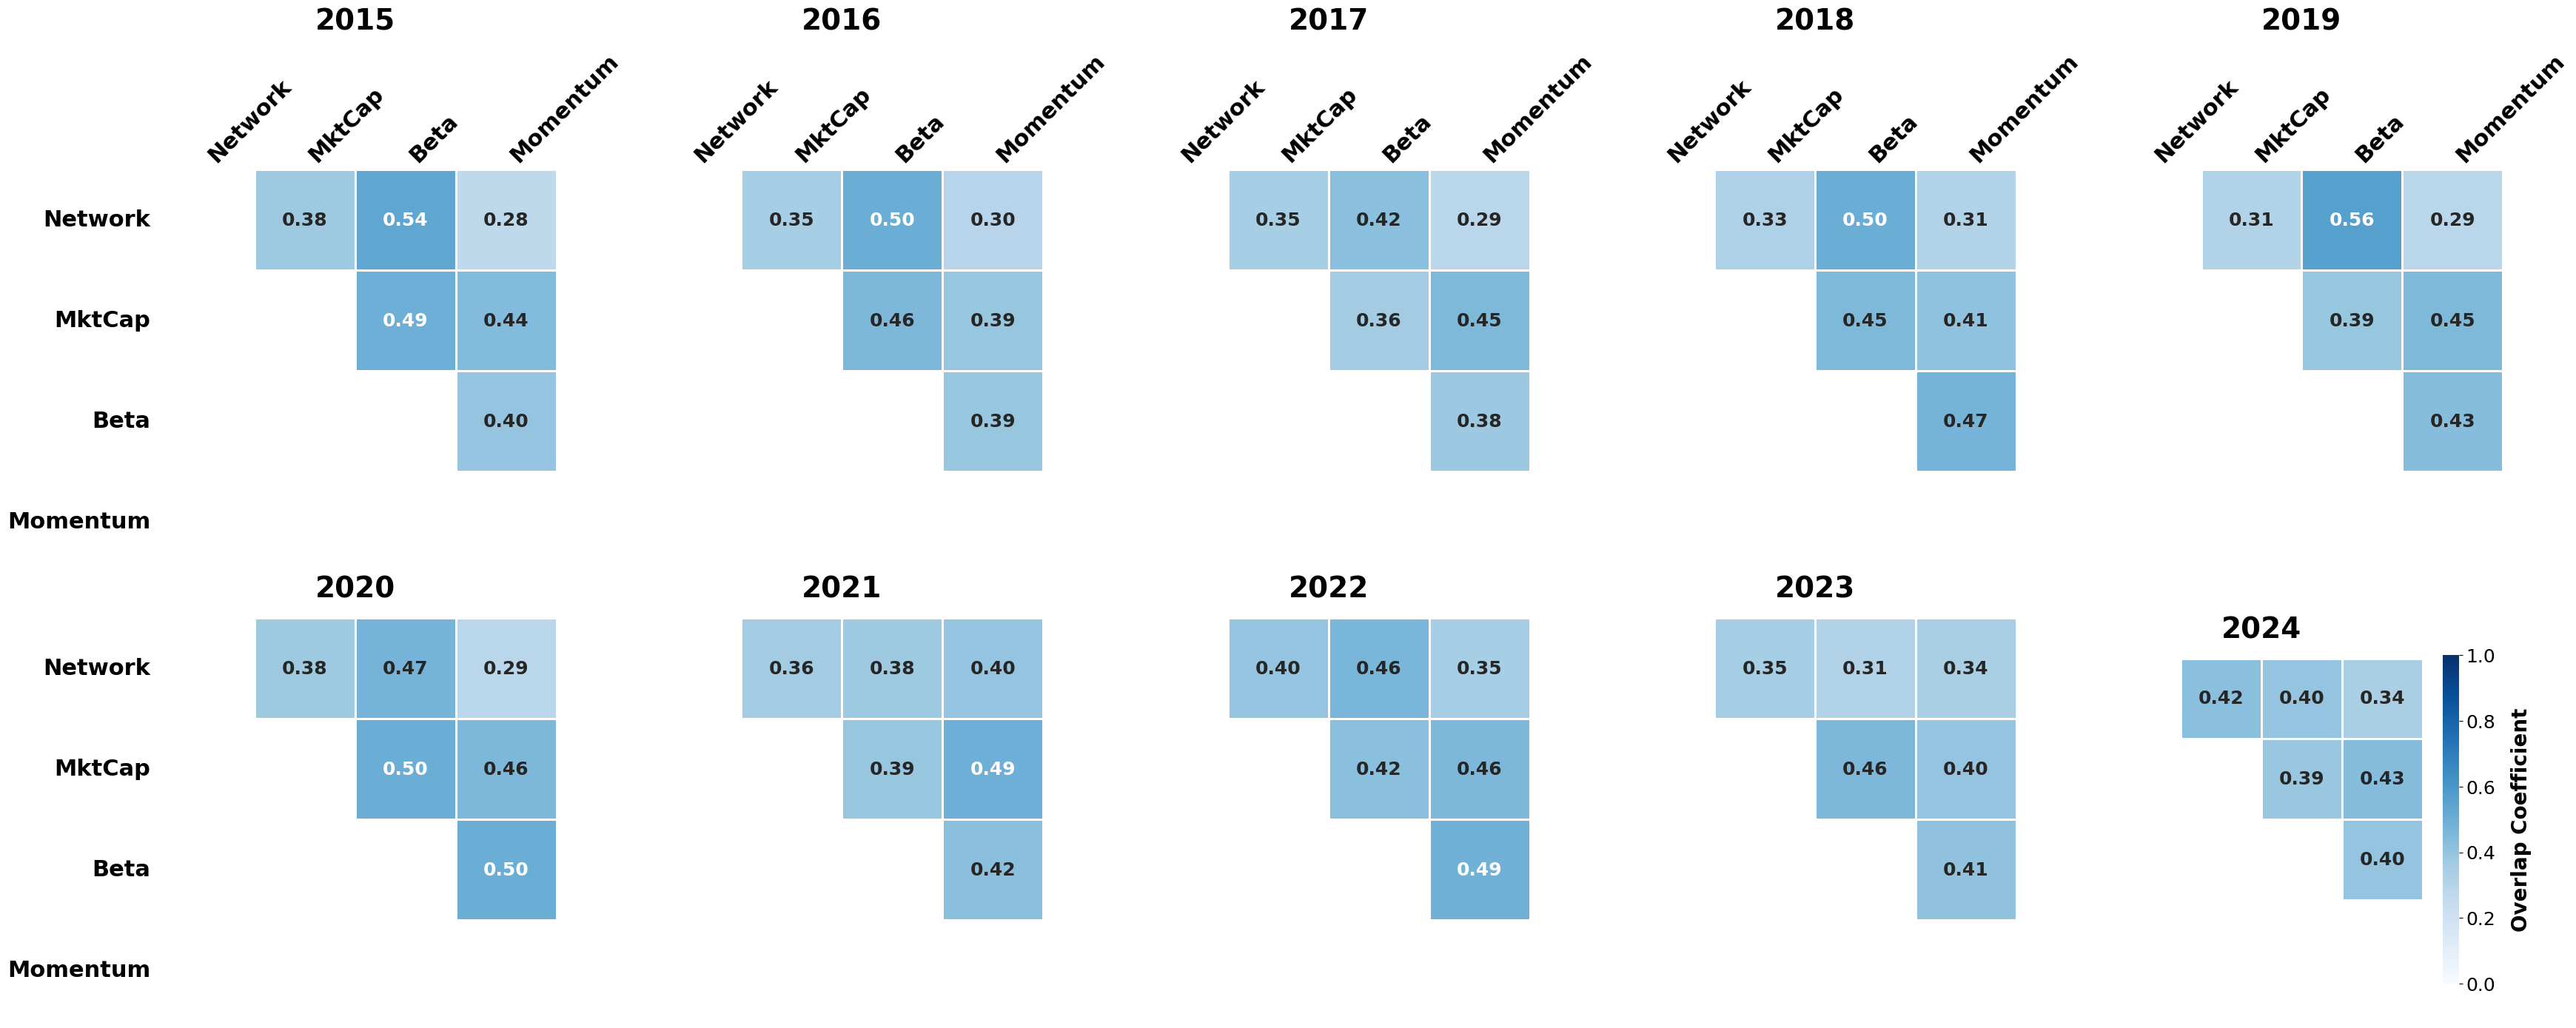

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

years = list(range(2015, 2025))
N = 80  # top + bottom stocks for metric portfolios

# --- helpers ---
def get_network_stocks(year):
    central   = set(central_portfolios[year]["node"])   if year in central_portfolios   else set()
    peripheral = set(peripheral_portfolios[year]["node"]) if year in peripheral_portfolios else set()
    return central | peripheral

def get_metric_stocks(col_pattern, year, n=N):
    col = col_pattern.format(year=year)
    if col not in final_df.columns:
        return set()
    s = final_df.dropna(subset=[col]).sort_values(col, ascending=False)
    return set(s.iloc[:n]["Ticker"]) | set(s.iloc[-n:]["Ticker"])

def overlap_coef(a, b):
    denom = min(len(a), len(b))
    return len(a & b) / denom if denom > 0 else 0.0

# column name patterns — adjust if yours differ
col_patterns = {
    "MktCap":   "mcap_{year}",
    "Beta":     "beta_{year}",
    "Momentum": "momentum_{year}",
}

labels = ["Network", "MktCap", "Beta", "Momentum"]

# --- FONT SIZE CONFIGURATION ---
TITLE_SIZE = 28
LABEL_SIZE = 22  
ANNOT_SIZE = 18
CBAR_LABEL_SIZE = 20

# Create figure - Adjusted to 2 rows and 5 columns for 10 years
fig, axes = plt.subplots(2, 5, figsize=(35, 14))
axes_flat = axes.flatten()

for i, year in enumerate(years):
    ax = axes_flat[i]
    
    # [Data processing remains same...]
    portfolios = {
        "Network":  get_network_stocks(year),
        "MktCap":   get_metric_stocks(col_patterns["MktCap"],   year),
        "Beta":     get_metric_stocks(col_patterns["Beta"],     year),
        "Momentum": get_metric_stocks(col_patterns["Momentum"], year),
    }

    mat = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for r in labels:
        for c in labels:
            mat.loc[r, c] = overlap_coef(portfolios[r], portfolios[c])

    # Show only UPPER matrix
    mask = np.tril(np.ones_like(mat, dtype=bool))

    sns.heatmap(
        mat.astype(float),
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0, vmax=1,
        linewidths=2,        # Increased for better grid visibility
        linecolor="white",   # The "grid" lines
        square=True,
        mask=mask,
        cbar=(i == 9),       # Updated: Show colorbar on the last plot (index 9)
        cbar_kws={"shrink": 0.8} if i == 9 else None,
        annot_kws={"size": ANNOT_SIZE, "weight": "bold"},
    )
    
    # Year Title
    ax.set_title(f"{year}", fontsize=TITLE_SIZE, fontweight="bold", pad=20)
    
    # --- Y-AXIS: Only show for the first column (index 0 and 5) ---
    if i % 5 == 0:
        ax.set_yticklabels(labels, rotation=0, fontsize=LABEL_SIZE, fontweight="bold")
    else:
        ax.set_yticklabels([]) # Removes labels but keeps the plot space
        ax.set_ylabel("")

    # --- X-AXIS: Only show for the top row (index 0, 1, 2, 3, 4) ---
    ax.xaxis.tick_top()
    if i < 5:
        ax.set_xticklabels(labels, rotation=45, ha="left", fontsize=LABEL_SIZE, fontweight="bold")
    else:
        ax.set_xticklabels([])

    # Ensure the white "grid" lines are not hidden
    ax.tick_params(axis="both", which="both", length=0)

# Final colorbar adjustment
if len(years) > 9: # Updated: Check if there's a 10th plot
    cbar = axes_flat[9].collections[0].colorbar
    cbar.set_label("Overlap Coefficient", fontsize=CBAR_LABEL_SIZE, fontweight="bold", labelpad=15)
    cbar.ax.tick_params(labelsize=LABEL_SIZE - 4)

plt.tight_layout()
plt.savefig(f"../../figures/window_{k}/overlap_heatmaps_by_year.png")
plt.show()

## Regression

In [88]:
temp = (
    pd.read_csv("../../data/02_clean/METADADOS_ATUALIZADO - Sheet1.csv")
      .replace({"#ERROR!": np.nan})
)

beta_momentum = pd.read_csv("../../data/07_portfolios_metadata/beta_momentum.csv", index_col="Unnamed: 0")

temp = temp.merge(
    beta_momentum,
    on=["Ticker"],
    how="left"
)

temp_long = pd.wide_to_long(
    temp,
    stubnames=['mcap', 'beta', 'momentum'], # The prefixes of your columns
    i='Ticker',                             # The unique identifier
    j='year',                               # The name of the new variable column
    sep='_',                                # The separator between prefix and year
    suffix=r'\d+'                           # Regex to match the year (digits)
).reset_index()

df['year'] = df['year'].astype(int)
temp_long['year'] = temp_long['year'].astype(int)

for col in ['mcap', 'beta', 'momentum']:
    if temp_long[col].dtype == 'object':
        temp_long[col] = temp_long[col].str.replace(',', '.').astype(float)

df = df.merge(
    temp_long[['Ticker', 'year', 'mcap', 'beta', 'momentum']], 
    on=['Ticker', 'year'], 
    how='left'
)

In [89]:
df

,node,hrm,pozzi,degree,closeness,eig,year,Ticker,Sector,mcap,beta,momentum
0,AAPL,-0.691521,0.282061,0.978617,0.159642,0.001037,2015,AAPL,Technology,5.805540e+11,1.142266,-0.001660
1,ACNT,-0.475758,0.244616,0.410390,0.194071,0.004625,2015,ACNT,Basic Materials,5.973216e+07,0.462641,-0.596467
2,ADI,0.465256,0.244243,4.195402,0.233479,0.017640,2015,ADI,Technology,1.721370e+10,1.297376,0.046246
3,ADP,-0.213325,0.300651,1.308448,0.198573,0.016697,2015,ADP,Technology,3.849677e+10,1.018333,0.062424
4,ALNT,-0.835324,0.280857,0.289305,0.154326,0.000228,2015,ALNT,Technology,3.632475e+08,1.191372,0.180378
...,...,...,...,...,...,...,...,...,...,...,...,...
385,TILE,-0.840253,0.322405,1.309205,0.161405,0.003719,2024,TILE,Consumer Cyclical,1.419727e+09,1.337066,0.950895
386,USLM,-0.464363,0.279467,0.854378,0.207750,0.010032,2024,USLM,Basic Materials,3.795568e+09,1.582290,1.934867
387,VALU,-0.377718,0.149184,0.638216,0.219112,0.012384,2024,VALU,Financial,4.972743e+08,0.650301,0.172990
388,VIRC,-0.869860,0.261669,0.335346,0.174176,0.002140,2024,VIRC,Consumer Cyclical,1.648926e+08,1.514142,-0.084880


In [90]:
k

30

In [91]:
df.to_parquet(f"../../data/02_clean/df_metrics_{k}.parquet")

In [119]:
df = df[~df["beta"].isna()]

df["log_mcap"] = np.log1p(df["mcap"])

df = df[~df["log_mcap"].isna()]

In [120]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def test_metric_orthogonality(df: pd.DataFrame) -> sm.regression.linear_model.RegressionResultsWrapper:
    """
    Runs a cross-sectional regression to prove the Hybrid score is not just 
    a linear combination of Beta, Market Cap, and Momentum.
    """
    # Define the dependent variable (The Network Metric)
    Y = df['hrm']
    
    # Define the independent variables (The standard factors)
    X = df[['beta', 'log_mcap', 'momentum']] #+ list(sector_dummies.columns)]
    
    # Add a constant (intercept) to the model
    X = sm.add_constant(X)
    
    # Fit the Ordinary Least Squares (OLS) regression
    model = sm.OLS(Y, X).fit()
    
    return model

sector_dummies = pd.get_dummies(df['Sector'], drop_first=True, prefix='Sector').astype(int)
df_reg = pd.concat([df, sector_dummies], axis=1)
r_squared_list = []
model_list = []
for year in years:
    df_year = df_reg[df_reg["year"]==year]
    model = test_metric_orthogonality(df_year)
    model_list.append(model)
    r_squared_list.append(model.rsquared)
    print(f"Year {year} R-squared: {model.rsquared:.4f}")

print(f"Average R-squared across all periods: {np.mean(r_squared_list):.4f}")

Year 2015 R-squared: 0.2923
Year 2016 R-squared: 0.4355
Year 2017 R-squared: 0.3723
Year 2018 R-squared: 0.5887
Year 2019 R-squared: 0.3417
Year 2020 R-squared: 0.3091
Year 2021 R-squared: 0.3156
Year 2022 R-squared: 0.5070
Year 2023 R-squared: 0.4001
Year 2024 R-squared: 0.2668
Average R-squared across all periods: 0.3829


In [121]:
import pandas as pd

# 1. Create a list of dictionaries to store results
results_list = []

for i, model in enumerate(model_list):
    # Start with the core metrics
    row = {
        'Year': years[i],
        'R_Squared': r_squared_list[i],
        'Intercept': model.params.get('const'),
        'Intercept_Pval': model.pvalues.get('const'),
        'Beta_Coef': model.params.get('beta'),
        'Beta_Pval': model.pvalues.get('beta'),
        'Mcap_Coef': model.params.get('log_mcap'),
        'Mcap_Pval': model.pvalues.get('log_mcap'),
        'Momentum_Coef': model.params.get('momentum'),
        'Momentum_Pval': model.pvalues.get('momentum')
    }
    
    # 2. Dynamically add all Sector dummies
    # This looks for any parameter starting with 'Sector_'
    for col in model.params.index:
        if col.startswith('Sector_'):
            row[f'{col}_Coef'] = model.params[col]
            row[f'{col}_Pval'] = model.pvalues[col]
            
    results_list.append(row)

# 3. Create the DataFrame
coef_df = pd.DataFrame(results_list)

# 4. Optional: Reorder columns to keep Year and R2 at the front
cols = ['Year', 'R_Squared'] + [c for c in coef_df.columns if c not in ['Year', 'R_Squared']]
coef_df = coef_df[cols]

print("\nYearly Summary (Including Sectors):")
pd.options.display.float_format = '{:.4f}'.format
print(coef_df)


Yearly Summary (Including Sectors):
   Year  R_Squared  Intercept  Intercept_Pval  Beta_Coef  Beta_Pval  \
0  2015     0.2923    -0.9560          0.3512     0.8665     0.0350   
1  2016     0.4355    -0.1721          0.8305     0.8768     0.0001   
2  2017     0.3723     0.0149          0.9900     1.2570     0.0001   
3  2018     0.5887    -1.3939          0.1167     1.7307     0.0000   
4  2019     0.3417    -0.9481          0.2217     0.5950     0.0029   
5  2020     0.3091    -1.9449          0.1105     1.5141     0.0021   
6  2021     0.3156     1.2018          0.3899     1.6062     0.0009   
7  2022     0.5070    -2.4647          0.0413     1.5915     0.0014   
8  2023     0.4001     0.9441          0.4111     1.5658     0.0001   
9  2024     0.2668     2.4144          0.1093     1.1183     0.0023   

   Mcap_Coef  Mcap_Pval  Momentum_Coef  Momentum_Pval  
0     0.0079     0.8927        -0.3174         0.3411  
1    -0.0409     0.3265         0.6659         0.0894  
2    -0.0532 

In [122]:
import pandas as pd

# Initialize empty lists for coefficients
const_coefs = []
beta_coefs = []
mcap_coefs = []
momentum_coefs = []

# Initialize empty lists for p-values
const_pvals = []
beta_pvals = []
mcap_pvals = []
momentum_pvals = []

# Loop through your saved models to extract params and p-values
for model in model_list:
    # Coefficients
    const_coefs.append(model.params['const'])
    beta_coefs.append(model.params['beta'])
    mcap_coefs.append(model.params['log_mcap'])
    momentum_coefs.append(model.params['momentum'])
    
    # P-values
    const_pvals.append(model.pvalues['const'])
    beta_pvals.append(model.pvalues['beta'])
    mcap_pvals.append(model.pvalues['log_mcap'])
    momentum_pvals.append(model.pvalues['momentum'])

# Create the expanded DataFrame
coef_df = pd.DataFrame({
    'Year': years,
    'Intercept': const_coefs,
    'Intercept_Pval': const_pvals,
    'Beta_Coef': beta_coefs,
    'Beta_Pval': beta_pvals,
    'Mcap_Coef': mcap_coefs,
    'Mcap_Pval': mcap_pvals,
    'Momentum_Coef': momentum_coefs,
    'Momentum_Pval': momentum_pvals,
    'R_Squared': r_squared_list
})

print("\nYearly Coefficient and P-Value Summary:")
pd.options.display.float_format = '{:.4f}'.format
print(coef_df)


Yearly Coefficient and P-Value Summary:
   Year  Intercept  Intercept_Pval  Beta_Coef  Beta_Pval  Mcap_Coef  \
0  2015    -0.9560          0.3512     0.8665     0.0350     0.0079   
1  2016    -0.1721          0.8305     0.8768     0.0001    -0.0409   
2  2017     0.0149          0.9900     1.2570     0.0001    -0.0532   
3  2018    -1.3939          0.1167     1.7307     0.0000     0.0038   
4  2019    -0.9481          0.2217     0.5950     0.0029     0.0161   
5  2020    -1.9449          0.1105     1.5141     0.0021     0.0217   
6  2021     1.2018          0.3899     1.6062     0.0009    -0.1324   
7  2022    -2.4647          0.0413     1.5915     0.0014     0.0585   
8  2023     0.9441          0.4111     1.5658     0.0001    -0.0948   
9  2024     2.4144          0.1093     1.1183     0.0023    -0.1406   

   Mcap_Pval  Momentum_Coef  Momentum_Pval  R_Squared  
0     0.8927        -0.3174         0.3411     0.2923  
1     0.3265         0.6659         0.0894     0.4355  
2     0.3

## Mcap portfolio

In [123]:
import pandas as pd
import numpy as np

years = range(2015, 2025)

# Load metadata and returns once outside the loop for efficiency
df_mcap_meta = pd.read_csv("../../data/02_clean/METADADOS_ATUALIZADO - Sheet1.csv")
df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
df_ret_full.index = pd.to_datetime(df_ret_full.index)
df_ret_full = df_ret_full[~df_ret_full.index.duplicated(keep='first')].sort_index()
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2019, 1, 1)]

for year in years:
    try:
        # 1. Load returns for the calculation window (e.g., year-9 to year)
        returns_fut = pd.read_parquet(f"../../data/02_clean/returns_{year + 1}.parquet")
        returns_prev = pd.read_parquet(f"../../data/02_clean/returns_{year - 9}_{year}.parquet")
        
        # 2. Market cap cleaning and quantile logic
        df_mcap_year = df_mcap_meta[(df_mcap_meta["Ticker"].isin(returns_prev.columns)) &
        (df_mcap_meta["Ticker"].isin(df_ret_full.columns))].copy()
        mcap_col = f"mcap_{year}"

        # Clean numeric data (handle dots and commas)
        df_mcap_year[mcap_col] = (
            df_mcap_year[mcap_col]
            .replace("#ERROR!", np.nan)
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        df_mcap_year[mcap_col] = pd.to_numeric(df_mcap_year[mcap_col], errors="coerce")
        df_mcap_year = df_mcap_year.dropna(subset=[mcap_col])

        # Define Portfolios based on p80/p20 quantiles
        p80 = df_mcap_year[mcap_col].quantile(0.8)
        p20 = df_mcap_year[mcap_col].quantile(0.2)

        large_tickers = df_mcap_year[df_mcap_year[mcap_col] >= p80]["Ticker"].tolist()
        small_tickers = df_mcap_year[df_mcap_year[mcap_col] <= p20]["Ticker"].tolist()

        large_caps = returns_fut[large_tickers]
        small_caps = returns_fut[small_tickers]

        large_caps.to_csv(f"../../data/06_portfolios/large_caps_{year}")
        small_caps.to_csv(f"../../data/06_portfolios/small_caps_{year}")
        
    except Exception as e:
        print(f"Error processing year {year}: {e}")
        continue

Error processing year 2015: [Errno 2] No such file or directory: '../../data/02_clean/returns_2016.parquet'
Error processing year 2016: [Errno 2] No such file or directory: '../../data/02_clean/returns_2017.parquet'
Error processing year 2017: [Errno 2] No such file or directory: '../../data/02_clean/returns_2018.parquet'
Error processing year 2018: [Errno 2] No such file or directory: '../../data/02_clean/returns_2009_2018.parquet'


In [124]:
import pandas as pd
import numpy as np

years = range(2019, 2025)

# Load metadata and returns once outside the loop for efficiency
df_mcap_meta = pd.read_csv("../../data/02_clean/METADADOS_ATUALIZADO - Sheet1.csv")
beta_momentum = pd.read_csv("../../data/07_portfolios_metadata/beta_momentum.csv", index_col="Unnamed: 0")
df_mcap_meta = df_mcap_meta.merge(beta_momentum, on="Ticker", how="left")
df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
df_ret_full.index = pd.to_datetime(df_ret_full.index)
df_ret_full = df_ret_full[~df_ret_full.index.duplicated(keep='first')].sort_index()
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2019, 1, 1)]

for year in years:
    try:
        # 1. Load returns for the calculation window (e.g., year-9 to year)
        returns_fut = pd.read_parquet(f"../../data/02_clean/returns_{year + 1}.parquet")
        returns_prev = pd.read_parquet(f"../../data/02_clean/returns_{year - 9}_{year}.parquet")
        
        # 2. Market cap cleaning and quantile logic
        df_mcap_year = df_mcap_meta[(df_mcap_meta["Ticker"].isin(returns_prev.columns)) &
        (df_mcap_meta["Ticker"].isin(df_ret_full.columns))].copy()
        mcap_col = f"momentum_{year}"

        # Clean numeric data (handle dots and commas)
        df_mcap_year[mcap_col] = (
            df_mcap_year[mcap_col]
            .replace("#ERROR!", np.nan)
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        df_mcap_year[mcap_col] = pd.to_numeric(df_mcap_year[mcap_col], errors="coerce")
        df_mcap_year = df_mcap_year.dropna(subset=[mcap_col])

        # Define Portfolios based on p80/p20 quantiles
        p80 = df_mcap_year[mcap_col].quantile(0.8)
        p20 = df_mcap_year[mcap_col].quantile(0.2)

        large_tickers = df_mcap_year[df_mcap_year[mcap_col] >= p80]["Ticker"].tolist()
        small_tickers = df_mcap_year[df_mcap_year[mcap_col] <= p20]["Ticker"].tolist()

        large_caps = returns_fut[large_tickers]
        small_caps = returns_fut[small_tickers]

        large_caps.to_csv(f"../../data/06_portfolios/large_momentum_{year}")
        small_caps.to_csv(f"../../data/06_portfolios/small_momentum_{year}")
        
    except Exception as e:
        print(f"Error processing year {year}: {e}")
        continue